In [4]:
#thư viện
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gensim.models.fasttext import load_facebook_model

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, Dropout,
    LayerNormalization, Bidirectional, LSTM, GRU,
    GlobalMaxPooling1D, Dense, Concatenate, Layer,
    SpatialDropout1D, Layer, Reshape
)
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, ComplementNB
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from gensim.models import KeyedVectors
#from focal_loss import SparseCategoricalFocalLoss
from sklearn.utils.class_weight import compute_class_weight
import torch
import gc
import keras
from sklearn.model_selection import train_test_split
#from pyvi import ViTokenizer

2026-04-14 18:59:17.084498: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776193157.302974      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776193157.372015      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776193157.889389      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776193157.889440      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776193157.889443      22 computation_placer.cc:177] computation placer alr

In [7]:
# 2. WRAPPER CHO CNN (CẦU NỐI ML + DL) (new)
# ==========================================
@keras.saving.register_keras_serializable(package="MyLayers")
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch_size, 4, 300) -> 4 nhánh, mỗi nhánh 300 filters
        self.W = self.add_weight(name="att_weight", 
                                 shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform",
                                 trainable=True)
        self.b = self.add_weight(name="att_bias", 
                                 shape=(input_shape[1], 1),
                                 initializer="zeros",
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # Tính toán điểm số quan trọng (score) cho từng nhánh [cite: 61, 78]
        # x shape: (batch_size, 4, 300), W shape: (300, 1) -> score shape: (batch_size, 4, 1)
        score = K.tanh(K.dot(x, self.W) + self.b)
        
        # Chuyển điểm số thành trọng số xác suất bằng Softmax [cite: 42, 61]
        weights = K.softmax(score, axis=1)
        
        # Nhân trọng số với đặc trưng và tổng hợp lại
        context_vector = x * weights
        return K.sum(context_vector, axis=1)

    def get_config(self):
        config = super().get_config()
        return config

class TransformerCNNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_name='dangvantuan/vietnamese-document-embedding', 
                 max_len=100, epochs=10, batch_size=32, device='cuda', X_val=None, y_val=None):
        self.model_name = model_name
        self.max_len = max_len
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device
        self.X_val = X_val
        self.y_val = y_val
        self.model = None
        self.embed_model = None
        self.classes_ = None

    def _get_embeddings(self, X):
        # Tải model transformer nếu chưa có
        if self.embed_model is None:
            from sentence_transformers import SentenceTransformer
            self.embed_model = SentenceTransformer(self.model_name, trust_remote_code=True).to(self.device)
        
        # Trích xuất token embeddings [cite: 37]
        features = self.embed_model.encode(X, output_value='token_embeddings', show_progress_bar=False)
        
        # Padding/Truncate về max_len [cite: 38]
        padded = []
        for f in features:
            f_np = f.cpu().numpy() if torch.is_tensor(f) else f
            if f_np.shape[0] >= self.max_len:
                padded.append(f_np[:self.max_len, :])
            else:
                pad_width = ((0, self.max_len - f_np.shape[0]), (0, 0))
                padded.append(np.pad(f_np, pad_width, mode='constant'))
        return np.array(padded)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        
        # Chuyển văn bản sang embedding
        X_embed = self._get_embeddings(X)
        val_data = None
        if self.X_val is not None and self.y_val is not None:
            val_data = (self._get_embeddings(self.X_val), self.y_val)

        # Xây dựng kiến trúc CNN + Attention từ file 3 [cite: 41]
        inputs = Input(shape=(self.max_len, 768)) # 768 là dim của vdn-embedding 
        x = SpatialDropout1D(0.2)(inputs)
        
        branches = []
        for size in [2, 3, 4, 5]: # Các kernel size [cite: 9, 41]
            branch = Conv1D(filters=300, kernel_size=size, padding='same', activation='relu')(x)
            branch = GlobalMaxPooling1D()(branch)
            branch = Reshape((1, 300))(branch)
            branches.append(branch)
            
        concat = Concatenate(axis=1)(branches)
        att_output = AttentionLayer()(concat)
        x = Dropout(0.4)(att_output)
        outputs = Dense(num_classes, activation='softmax')(x)
        
        self.model = Model(inputs=inputs, outputs=outputs)
        self.model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        # Huấn luyện [cite: 42]
        self.model.fit(X_embed, y, epochs=self.epochs, batch_size=self.batch_size,
                      validation_data=val_data, verbose=0,
                      callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])

        # Xóa các ma trận embedding khổng lồ khỏi RAM
        del X_embed
        if val_data is not None:
            del val_data
            
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        
        return self

    def predict_proba(self, X):
        X_embed = self._get_embeddings(X)
        return self.model.predict(X_embed, verbose=0)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def __getstate__(self):
        import tempfile
        import os
        state = self.__dict__.copy()
        
        # Bỏ qua SentenceTransformer, nó sẽ tự động tải lại [cite: 7]
        state['embed_model'] = None
        
        # Biến Keras model thành dạng bytes để nhét vào joblib [cite: 12]
        if self.model is not None:
            fd, path = tempfile.mkstemp(suffix='.keras')
            os.close(fd)
            self.model.save(path)
            with open(path, 'rb') as f:
                state['keras_model_bytes'] = f.read()
            os.remove(path)
            
        state['model'] = None
        return state

    def __setstate__(self, state):
        import os
        from tensorflow.keras.models import load_model
        
        keras_model_bytes = state.pop('keras_model_bytes', None)
        self.__dict__.update(state)
        
        # Khôi phục lại Keras model từ bytes
        if keras_model_bytes is not None:
            fd, path = tempfile.mkstemp(suffix='.keras')
            with os.fdopen(fd, 'wb') as f:
                f.write(keras_model_bytes)
            # Khôi phục thành công
            self.model = load_model(path)
            os.remove(path)


In [8]:
def preprocess_text(text):
    emo_dict = {
        "😕": " bối rối ",      # Confused face
        "😝": " trêu chọc ",    # Squinting face with tongue (trêu đùa)
        "😣": " chịu đựng ",    # Persevering face (cố kìm nén, khổ sở)
        "🌧": " mưa buồn ",     # Cloud with rain (thường dùng khi tâm trạng buồn)
        "🥵": " vã mồ hôi ",
        
        # --- Nhóm Tích cực (Vui, Cười, Yêu thích) ---
        "😂": " cười vui ",    "🤣": " cười lăn lộn ", "😁": " cười tươi ", 
        "😊": " cười mỉm ",    "🙂": " cười nhẹ ",     "😆": " cười lớn ", 
        "😄": " vui vẻ ",      "😃": " vui ",          "😀": " hạnh phúc ", 
        "😅": " cười trừ ",    "😍": " yêu thích ",    "🥰": " yêu thương ", 
        "😘": " hôn ",         "😚": " hôn gió ",      "💋": " nụ hôn ", 
        "💕": " yêu ",         "💗": " trái tim ",     "💓": " tim đập ", 
        "😻": " mê mẩn ",      "🤩": " tuyệt vời ",    "🤪": " tinh nghịch ", 
        "😜": " trêu đùa ",    "🤗": "ôm",           "🌸": " hoa đẹp ", 
        "👏": " hoan hô ",     "👍": "tốt",          "👌": " ok ", 
        "💪": " cố lên ",      "😎": "ngầu",         "😋": " ngon ", 
        "😹": " cười ra nước mắt ", "💃": "nhảy múa", "🌝": " vui vẻ ", 

        # --- Nhóm Tiêu cực (Buồn, Khóc, Thất vọng) ---
        "😭": " khóc lớn ",    "😢": " buồn khóc ",    "😔": " buồn ", 
        "😞": " thất vọng ",   "☹": " buồn rầu ",      "🙁": " lo lắng ", 
        "😟": " lo âu ",       "😥": " toát mồ hôi ",  "😓": " lo sợ ", 
        "😿": " mèo khóc ",    "💔": " đau lòng ",     "😩": " than thở ", 
        "😫": " mệt mỏi ",     "😪": " buồn ngủ ",     "😴": " ngủ ", 
        "🤕": " bị thương ",   "🥀": " héo úa ",       "👎": " tệ ", 

        # --- Nhóm Tức giận, Khó chịu ---
        "😡": " giận dữ ",     "😠": " phẫn nộ ",      "🤬": " chửi bới ", 
        "😤": " bực mình ",    "😒": " khó chịu ",     "🙄": " ngán ngẩm ", 
        "😑": " cạn lời ",     "😐": " ba chấm ",      "😶": " im lặng ", 
        "😖": " khổ sở ",      "🤢": " buồn nôn ",     "🤮": " ghê tởm ", 
        "👎": " chê ",         "💩": " tệ hại ",       "👺": " quỷ ", 

        # --- Nhóm Ngạc nhiên, Sợ hãi ---
        "😱": " hoảng hốt ",   "😨": " sợ hãi ",       "😰": " lo lắng tột độ ", 
        "😳": " ngại ngùng ",  "😮": " ngạc nhiên ",   "😧": " sững sờ ", 
        "😦": " sốc ",         "🤯": " nổ não ",       "😬": " lo ngại ", 

        # --- Nhóm Thái độ, Mỉa mai, Khác ---
        "😌": " nhẹ nhõm ",    "😏": " nhếch mép ",    "🤔": " suy nghĩ ", 
        "🙃": " cười ngược ",  "🤭": " cười che miệng ","🤐": " kín miệng ", 
        "🧐": " soi xét ",     "🤨": " nghi ngờ ",     "🤠": " cao bồi ", 
        "😈": " ác quỷ ",      "👻": " ma ",           "💀": " chết chóc ", 
        "🌚": " đen tối ",     "🤤": " thèm thuồng ",  "🤧": " hắt hơi ", 
        "😷": " đeo khẩu trang ","🤫": " trật tự ",    "🙏": " cầu nguyện ", 
        "🤦": " bó tay ",      "🤷": " không biết ",   "🙎": " dỗi ", 

        # --- Xử lý các icon đặc biệt hoặc vô nghĩa ---
        "🏻": "", "🏼": "", "🏽": "", "🏾": "", "🏿": "", # Màu da -> xóa
        "🕸": " mạng nhện ",   "🐶": " chó ",          "🐕": " chó ", 
        "🤑": " tham tiền ",   "😗": " hôn nhẹ ",      "😉": " nháy mắt "
    }
    for emo, word in emo_dict.items():
        text = text.replace(emo, word)
        
    #text = ViTokenizer.tokenize(text)
    
    # 2. Chuyển thành chữ thường
    text = text.lower()
    
    # 3. Thay thế dấu câu bằng khoảng trắng
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # 4. Xóa Stop words bằng danh sách vietnamese_stopwords mới
    # words = text.split()
    # filtered_words = [word for word in words if word not in vietnamese_stopwords]
    # text = " ".join(filtered_words)
    
    # 5. DỌN DẸP KHOẢNG TRẮNG THỪA VÀ KHOẢNG TRẮNG ĐẦU/CUỐI CÂU
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

--- Đang chuẩn bị dữ liệu ---

--- 10 DÒNG ĐẦU CỦA TẬP TRAIN SAU TIỀN XỬ LÝ ---

--- Testing lr_tfidf ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5916
F1: 0.5952

--- Testing nb_tfidf ---
y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5397
F1: 0.5356

--- Testing svm_tfidf ---
y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5743
F1: 0.5692

--- Testing xgb_tfidf ---
y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5599
F1: 0.5530

--- Testing knn ---
y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.4834
F1: 0.4516

--- Testing rf ---
y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5440
F1: 0.5295

--- Testing cnn_transformer ---


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

...

I0000 00:00:1776193354.076227      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13725 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1776193362.761390     113 service.cc:152] XLA service 0x7fbf8008ccf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776193362.761434     113 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776193363.274053     113 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776193367.118872     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


y_test shape: (693,)
y_pred shape: (693,)
Accuracy: 0.5859
F1: 0.5805

--- Đang huấn luyện mô hình Hybrid Stacking (Vui lòng đợi...) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


BẢNG SO SÁNH:
             Model  Accuracy  F1_weighted
7         stacking  0.655123     0.653078
0         lr_tfidf  0.591631     0.595158
6  cnn_transformer  0.585859     0.580496
2        svm_tfidf  0.574315     0.569163
3        xgb_tfidf  0.559885     0.552963
1         nb_tfidf  0.539683     0.535601
5               rf  0.544012     0.529453
4              knn  0.483405     0.451609
LogisticRegression()
LogisticRegression(C=4.5, class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42)

KẾT QUẢ KIỂM THỬ TRÊN TẬP TEST
Accuracy: 0.6551
F1-Score (Weighted): 0.6531
F1-Score (Macro): 0.6149

BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

       Anger       0.48      0.40      0.44        40
     Disgust       0.56      0.72      0.63       132
   Enjoyment       0.74      0.75      0.74       193
        Fear       0.79      0.67      0.73        46
       Other       0.58      0.61      0.60       129
     Sadnes

/tmp/ipykernel_22/4260312364.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Accuracy', 'F1-Score'], y=[acc, f1_weighted], palette='viridis')


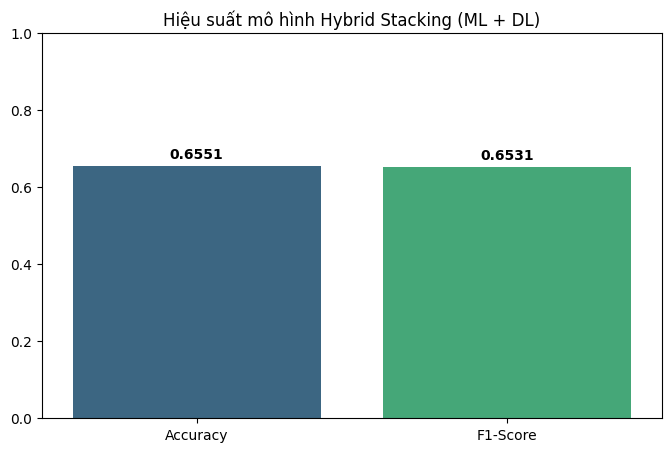

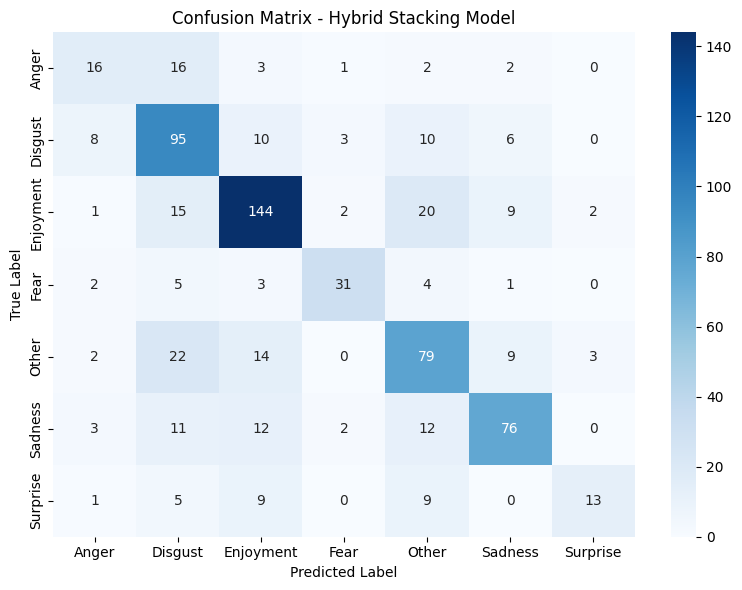

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
print("--- Đang chuẩn bị dữ liệu ---")

# 2. Load và Preprocess dữ liệu
train_df = pd.read_csv("/kaggle/input/datasets/nguynngcthng62/emotion-all/train_corrected.csv")
dev_df = pd.read_csv("/kaggle/input/datasets/nguynngcthng62/emotion-all/dev_corrected.csv")
val_df = pd.read_csv("/kaggle/input/datasets/nguynngcthng62/emotion-all/test_corrected.csv")

# Xóa từ "per" và Preprocess đúng biến
for df in [train_df, dev_df, val_df]:
    df['text_corrected'] = df['text_corrected'].str.replace(r'\bper\b', '', regex=True, case=False)
    df['text_corrected'] = df['text_corrected'].apply(preprocess_text)

print("\n--- 10 DÒNG ĐẦU CỦA TẬP TRAIN SAU TIỀN XỬ LÝ ---")
# Chỉ in 2 cột quan trọng nhất cho dễ nhìn
# print(train_df[['Emotion', 'text_corrected', 'Sentence']].head(10)) 
# print("==========================================\n")

le = LabelEncoder()
y_train = le.fit_transform(train_df['Emotion'])
y_dev = le.transform(dev_df['Emotion'])  # Thêm encode cho dev
y_test = le.transform(val_df['Emotion'])
        
num_classes = len(le.classes_)
from catboost import CatBoostClassifier

# Chuẩn bị dữ liệu cho stacking
X_train_raw = train_df['text_corrected'].values
X_dev_raw = dev_df['text_corrected'].values  # Thêm dev data
X_val_raw = val_df['text_corrected'].values
# ==========================================
# 4. XÂY DỰNG HYBRID STACKING
# ==========================================
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),      # Cập nhật theo Bảng IX: (1, 3)
    max_features=25000,      # Cập nhật theo Bảng IX: 25.000 features
    min_df=2,                # Giữ nguyên để lọc các từ hiếm
    max_df=0.95              # Giữ nguyên để lọc các từ quá phổ biến
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

labels, counts = np.unique(y_train, return_counts=True)
emotion_counts_dict = dict(zip(labels, counts))

# Khai báo các mô hình lớp 0 (ML + DL)
level0 = [
    ('lr_tfidf', Pipeline([('tfidf', tfidf), ('clf', LogisticRegression(C=4.5,                        # Cập nhật theo Mục V.B: C = 4.5
            class_weight='balanced',      # Cập nhật theo Mục V.B: Cân bằng class
            multi_class='multinomial',    # Chuyển thành MLR (Multinomial LR)
            solver='lbfgs',               # Solver bắt buộc cho multinomial
            max_iter=1000,
            random_state=42))])),
    ('nb_tfidf', Pipeline([('tfidf', tfidf), ('clf', ComplementNB(alpha=0.1))])),
    ('svm_tfidf', Pipeline([('tfidf', tfidf), ('clf', SVC(kernel='linear', probability=True))])),
    ('xgb_tfidf', Pipeline([
        ('tfidf', tfidf), 
        ('clf', XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
        ))
    ])),
    ('knn', Pipeline([('tfidf', tfidf), ('clf', KNeighborsClassifier(n_neighbors=21))])),
    ('rf', Pipeline([('tfidf', tfidf), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])),

    ('cnn_transformer', TransformerCNNWrapper(
        model_name='dangvantuan/vietnamese-document-embedding',
        max_len=100, 
        epochs=30, 
        X_val=X_dev_raw, 
        y_val=y_dev
    ))
   
]


# =========================
# A. Test từng model riêng
# =========================
individual_results = []

for name, model in level0:
    print(f"\n--- Testing {name} ---")
    model.fit(X_train_raw, y_train)
    y_pred_model = model.predict(X_val_raw)

    y_pred_model = np.array(y_pred_model)
    y_test_eval = np.array(y_test)

    print("y_test shape:", y_test_eval.shape)
    print("y_pred shape:", y_pred_model.shape)

    # Nếu output là xác suất / one-hot -> chuyển thành label
    if y_pred_model.ndim > 1:
        y_pred_model = np.argmax(y_pred_model, axis=1)

    acc_model = accuracy_score(y_test_eval, y_pred_model)
    f1_model = f1_score(y_test_eval, y_pred_model, average='weighted')

    individual_results.append({
        'Model': name,
        'Accuracy': acc_model,
        'F1_weighted': f1_model
    })

    print(f"Accuracy: {acc_model:.4f}")
    print(f"F1: {f1_model:.4f}")

# =========================
# B. Test stacking
# =========================

# Meta-model
final_ensemble = StackingClassifier(
    estimators=level0,
    final_estimator=LogisticRegression(),
    stack_method='predict_proba',
    cv=skf,
    n_jobs=1 # Đặt 1 vì có model DL
)

# ==========================================
# 5. HUẤN LUYỆN & KIỂM THỬ (PHẦN BẠN CẦN)
# ==========================================
print("\n--- Đang huấn luyện mô hình Hybrid Stacking (Vui lòng đợi...) ---")


final_ensemble.fit(X_train_raw, y_train)

y_pred_stack = final_ensemble.predict(X_val_raw)

acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack, average='weighted')

individual_results.append({
    'Model': 'stacking',
    'Accuracy': acc_stack,
    'F1_weighted': f1_stack
})

# =========================
# C. Tổng hợp kết quả
# =========================
results_df = pd.DataFrame(individual_results)
print("\nBẢNG SO SÁNH:")
print(results_df.sort_values(by='F1_weighted', ascending=False))

print(final_ensemble.final_estimator)
print(level0[0][1].named_steps['clf'])

print("=====================================================================================================================================")

print("\n" + "="*50)
print("KẾT QUẢ KIỂM THỬ TRÊN TẬP TEST")
y_pred = final_ensemble.predict(X_val_raw)

# Tính Accuracy và F1-Score
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro    = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {acc:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print("\nBÁO CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ==========================================
# 6. TRỰC QUAN HÓA
# ==========================================
plt.figure(figsize=(8, 5))
sns.barplot(x=['Accuracy', 'F1-Score'], y=[acc, f1_weighted], palette='viridis')
plt.title("Hiệu suất mô hình Hybrid Stacking (ML + DL)")
plt.ylim(0, 1)
for i, v in enumerate([acc, f1_weighted]):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tính confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Hybrid Stacking Model')
plt.tight_layout()
plt.show()

In [13]:
import joblib

# 1. Lưu mô hình Stacking
model_filename = 'hybrid_stacking_vsmec_sentiment.joblib'
joblib.dump(final_ensemble, model_filename)
print(f"Đã lưu mô hình tại: {model_filename}")

# 2. Lưu LabelEncoder (quan trọng để giải mã nhãn Emotion)
le_filename = 'label_encoder.joblib'
joblib.dump(le, le_filename)
print(f"Đã lưu LabelEncoder tại: {le_filename}")

Đã lưu mô hình tại: hybrid_stacking_vsmec_sentiment.joblib
Đã lưu LabelEncoder tại: label_encoder.joblib
